In [3]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124 --timeout 1000

Looking in indexes: https://download.pytorch.org/whl/cu124
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install scikit-learn matplotlib seaborn pandas numpy tqdm Pillow

Note: you may need to restart the kernel to use updated packages.


## Importing all libraries



In [5]:
import os, time, copy, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import transforms, models, datasets
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch : 2.6.0+cu124
CUDA    : True
GPU     : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM    : 4.3 GB


## Configing with dataset


In [6]:
DATASET_ROOT = r"/mnt/c/game/Assessment_AI/PART-2/Traffic_Sign/Traffic_Sign"


TRAIN_DIR = os.path.join(DATASET_ROOT, "Train")
TEST_DIR  = os.path.join(DATASET_ROOT, "Test")

# Image sizes
IMG_SIZE    = 64    # Part A — from scratch CNNs
IMG_SIZE_TL = 128   # Part B — EfficientNet-B0 (fits in 4GB VRAM)

# Training settings
BATCH_SIZE = 16     # Safe for RTX 3050 4GB
VAL_SPLIT  = 0.20   # 80% train, 20% validation
SEED       = 42
NUM_WORKERS = 0     # 0 = safest on Windows/WSL

# Device — uses GPU if available
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

# Fix random seeds for reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)

# ImageNet normalisation values (used for all models)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

Device : cuda


## Handling corrupt files


In [7]:
def load_image_safe(path):
    """
    Try to open an image file.
    Returns a PIL Image if successful, or None if the file is corrupted.
    """
    try:
        img = Image.open(path)
        img.verify()                        # catches truncated / broken files
        img = Image.open(path).convert("RGB")  # re-open after verify
        return img
    except Exception:
        return None   # silently skip bad files


class SafeImageFolder(datasets.ImageFolder):
    """
    Works exactly like PyTorch ImageFolder but skips corrupted images
    instead of crashing.  Returns a blank black tensor for bad files
    so the DataLoader batch size stays consistent.
    """
    def __getitem__(self, index):
        path, label = self.samples[index]
        try:
            img = load_image_safe(path)
            if img is None:
                raise ValueError("corrupt")
            if self.transform:
                img = self.transform(img)
            return img, label
        except Exception:
            # Return black image tensor for corrupted files
            size = getattr(self, "img_size", 64)
            return torch.zeros(3, size, size), label


print("Safe image loader ready.")

Safe image loader ready.


## Dataset Analysis
Count images per class and check for corrupted files.

In [8]:
assert os.path.isdir(TRAIN_DIR), f"Train folder not found: {TRAIN_DIR}"
assert os.path.isdir(TEST_DIR),  f"Test folder not found:  {TEST_DIR}"

VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.ppm', '.bmp', '.pgm'}

# Discover classes from subfolder names
class_names = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])
print(f"Classes ({len(class_names)}): {class_names}")

# Count valid and corrupted images per class
class_stats = {}
total_corrupt = 0

for cls in class_names:
    folder = os.path.join(TRAIN_DIR, cls)
    files  = [f for f in os.listdir(folder)
               if Path(f).suffix.lower() in VALID_EXTENSIONS]
    good = bad = 0
    for fname in files:
        img = load_image_safe(os.path.join(folder, fname))
        if img is None: bad += 1
        else:           good += 1
    class_stats[cls] = {"total": len(files), "valid": good, "corrupt": bad}
    total_corrupt += bad

# Print summary table
print(f"\n{'Class':<22} {'Total':>7} {'Valid':>7} {'Corrupt':>8}")
print("─" * 47)
for cls, s in class_stats.items():
    print(f"{cls:<22} {s['total']:>7} {s['valid']:>7} {s['corrupt']:>8}")
print("─" * 47)
total_valid = sum(s["valid"] for s in class_stats.values())
total_all   = sum(s["total"] for s in class_stats.values())
print(f"{'TOTAL':<22} {total_all:>7} {total_valid:>7} {total_corrupt:>8}")

# Count test images
test_files = [f for f in os.listdir(TEST_DIR)
              if Path(f).suffix.lower() in VALID_EXTENSIONS]
print(f"\nTest images : {len(test_files)}")

Classes (4): ['Caution', 'Instructions', 'No Passing', 'OverSpeed']

Class                    Total   Valid  Corrupt
───────────────────────────────────────────────
Caution                   2422    2422        0
Instructions              2841    2841        0
No Passing                5362    5362        0
OverSpeed                 5242    5242        0
───────────────────────────────────────────────
TOTAL                    15867   15867        0

Test images : 4


##  Class Distribution Charts


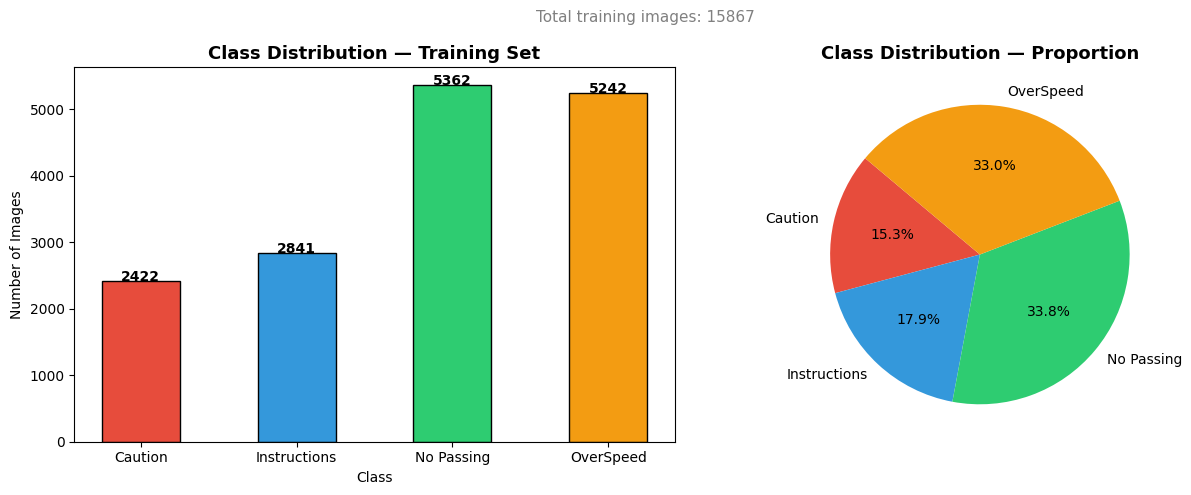

Saved: 01_class_distribution.png


In [9]:
valid_counts = [class_stats[c]["valid"] for c in class_names]
colors       = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bars = axes[0].bar(class_names, valid_counts, color=colors, edgecolor="black", width=0.5)
axes[0].set_title("Class Distribution — Training Set", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Images")
for bar, count in zip(bars, valid_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1, str(count), ha="center", fontweight="bold")

# Pie chart
axes[1].pie(valid_counts, labels=class_names, autopct="%1.1f%%",
            colors=colors, startangle=140)
axes[1].set_title("Class Distribution — Proportion", fontsize=13, fontweight="bold")

plt.suptitle(f"Total training images: {total_valid}", fontsize=11, color="gray")
plt.tight_layout()
plt.savefig("01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 01_class_distribution.png")

## Sample Images per Class

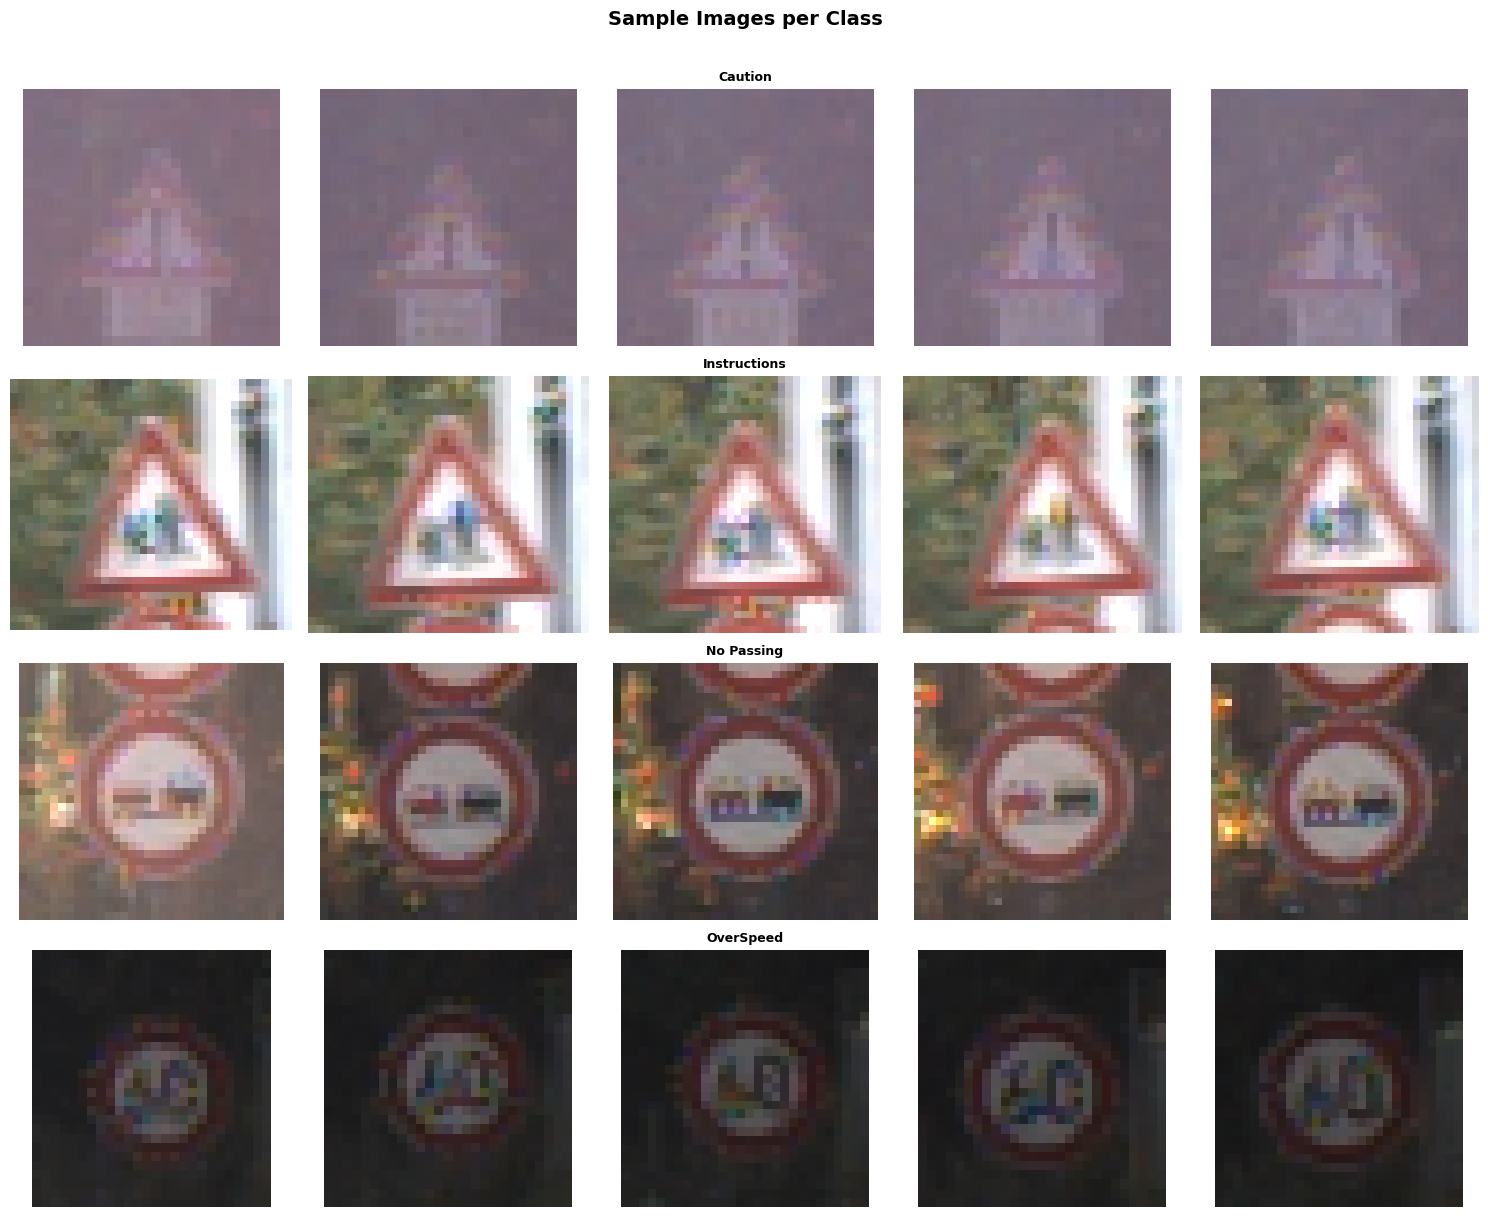

Saved: 02_sample_images.png


In [10]:
N = 5   # samples per class
fig, axes = plt.subplots(len(class_names), N, figsize=(3*N, 3*len(class_names)))

for row, cls in enumerate(class_names):
    folder = os.path.join(TRAIN_DIR, cls)
    files  = [f for f in os.listdir(folder)
               if Path(f).suffix.lower() in VALID_EXTENSIONS]
    shown  = 0
    for fname in files:
        if shown >= N: break
        img = load_image_safe(os.path.join(folder, fname))
        if img:
            axes[row, shown].imshow(img)
            axes[row, shown].set_title(cls if shown == 2 else "", fontsize=9, fontweight="bold")
            axes[row, shown].axis("off")
            shown += 1
    while shown < N:
        axes[row, shown].axis("off")
        shown += 1

plt.suptitle("Sample Images per Class", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("02_sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 02_sample_images.png")

## Data Augmentation Visualisation
Shows what augmented training images look like before feeding into the model.

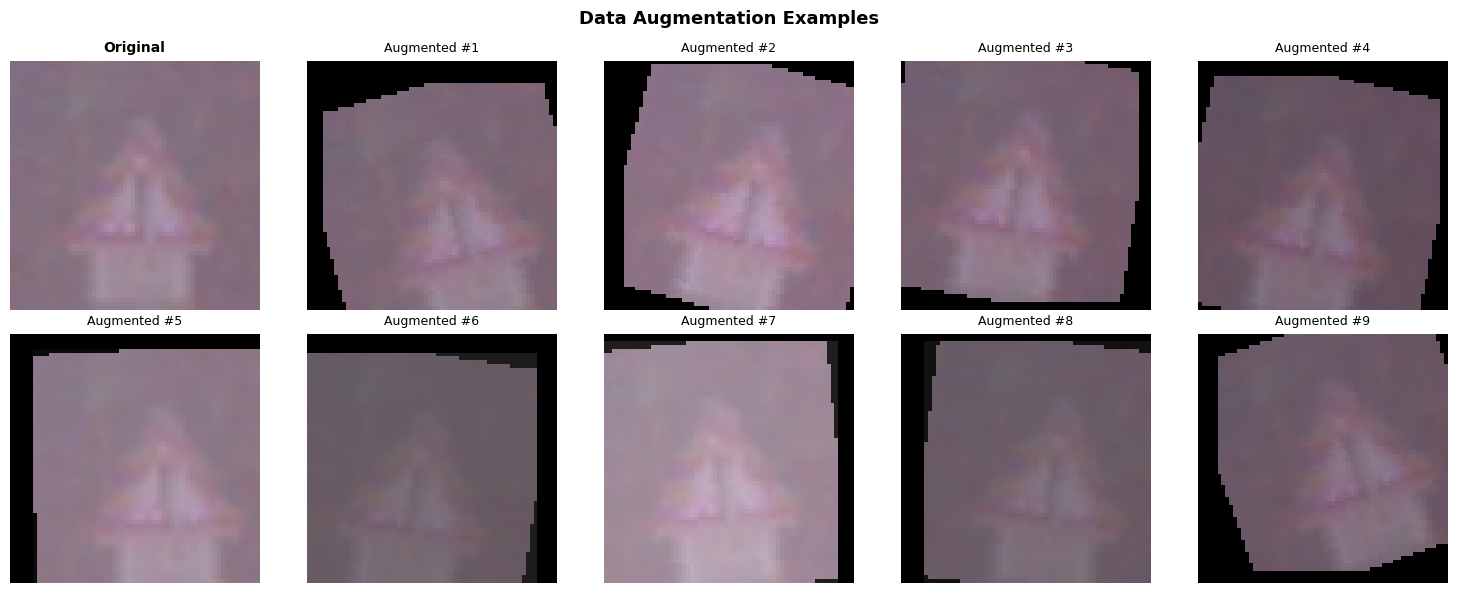

Saved: 03_augmentation.png


In [11]:
# Augmentation transforms used during training
augmentation = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(20),                          # rotate up to 20 degrees
    transforms.ColorJitter(brightness=0.3, contrast=0.3),  # lighting variation
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # slight position shift
    # NOTE: No horizontal flip — a mirrored "60" speed sign looks wrong
])

# Find one sample image to demonstrate augmentation
sample_img = None
for cls in class_names:
    folder = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(folder):
        if Path(fname).suffix.lower() in VALID_EXTENSIONS:
            img = load_image_safe(os.path.join(folder, fname))
            if img:
                sample_img = img
                break
    if sample_img: break

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0, 0].imshow(sample_img.resize((IMG_SIZE, IMG_SIZE)))
axes[0, 0].set_title("Original", fontsize=10, fontweight="bold")
axes[0, 0].axis("off")

for i in range(1, 10):
    aug = augmentation(sample_img)
    r, c = divmod(i, 5)
    axes[r, c].imshow(aug)
    axes[r, c].set_title(f"Augmented #{i}", fontsize=9)
    axes[r, c].axis("off")

plt.suptitle("Data Augmentation Examples", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("03_augmentation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 03_augmentation.png")

##  DataLoaders for Part A (64×64)

- Resize to 64×64 — small enough to train fast, large enough to see sign detail
- Normalise with ImageNet mean/std — standard practice, helps convergence
- Augmentation on train only (not validation) — prevents data leakage

In [12]:
# Training transform — includes augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Validation/test transform — clean images only, no augmentation
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Load full training dataset with augmentation
full_dataset          = SafeImageFolder(TRAIN_DIR, transform=train_transform)
full_dataset.img_size = IMG_SIZE
NUM_CLASSES           = len(full_dataset.classes)
CLASS_NAMES           = full_dataset.classes

# Split into 80% train / 20% validation
val_size   = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size

train_dataset, val_split = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Give validation set the clean transform (no augmentation)
val_dataset_clean          = SafeImageFolder(TRAIN_DIR, transform=val_transform)
val_dataset_clean.img_size = IMG_SIZE
val_dataset                = Subset(val_dataset_clean, val_split.indices)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print(f"Classes     : {CLASS_NAMES}")
print(f"Num classes : {NUM_CLASSES}")
print(f"Train size  : {train_size:,}  |  Val size : {val_size:,}")
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

Classes     : ['Caution', 'Instructions', 'No Passing', 'OverSpeed']
Num classes : 4
Train size  : 12,694  |  Val size : 3,173
Train batches: 794  |  Val batches: 199


## Training & Evaluation Functions
Reusable functions used by all models throughout the notebook.

In [13]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    """Run one training epoch. Returns average loss and accuracy."""
    model.train()
    total_loss = total_correct = total_samples = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        predictions = model(images)
        loss        = loss_fn(predictions, labels)
        loss.backward()
        optimizer.step()

        total_loss    += loss.item() * images.size(0)
        total_correct += (predictions.argmax(1) == labels).sum().item()
        total_samples += images.size(0)

    return total_loss / total_samples, total_correct / total_samples


def evaluate(model, loader, loss_fn, device):
    """Evaluate model on a data loader. Returns loss, accuracy, all predictions and labels."""
    model.eval()
    total_loss = total_correct = total_samples = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            predictions    = model(images)
            loss           = loss_fn(predictions, labels)

            total_loss    += loss.item() * images.size(0)
            preds          = predictions.argmax(1)
            total_correct += (preds == labels).sum().item()
            total_samples += images.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / total_samples, total_correct / total_samples, all_preds, all_labels


def train_model(model, train_loader, val_loader, loss_fn, optimizer,
                scheduler=None, num_epochs=25, device=DEVICE, model_name="model"):
    """
    Full training loop with:
    - Best model checkpoint (saved to disk)
    - Training history (loss + accuracy per epoch)
    - Elapsed time tracking
    """
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc  = 0.0
    best_weights  = copy.deepcopy(model.state_dict())
    start_time    = time.time()

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        va_loss, va_acc, _, _ = evaluate(model, val_loader, loss_fn, device)

        if scheduler:
            scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        # Save best model weights
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_weights = copy.deepcopy(model.state_dict())

        # Print every 5 epochs
        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{num_epochs} | "
                  f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc*100:5.2f}% | "
                  f"Val Loss: {va_loss:.4f}  Acc: {va_acc*100:5.2f}%")

    elapsed = time.time() - start_time
    model.load_state_dict(best_weights)
    torch.save(model.state_dict(), f"{model_name}_best.pth")
    print(f"\n  Best Val Accuracy : {best_val_acc*100:.2f}%")
    print(f"  Training Time     : {elapsed:.1f}s ({elapsed/60:.1f} min)")
    return model, history, elapsed, best_val_acc


def plot_training_curves(history, title, save_path=None):
    """Plot training vs validation loss and accuracy side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Loss plot
    axes[0].plot(history["train_loss"], label="Train", color="#e74c3c", linewidth=2)
    axes[0].plot(history["val_loss"],   label="Val",   color="#3498db", linewidth=2)
    axes[0].set_title(f"{title} — Loss",     fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Accuracy plot
    axes[1].plot([v*100 for v in history["train_acc"]], label="Train", color="#e74c3c", linewidth=2)
    axes[1].plot([v*100 for v in history["val_acc"]],   label="Val",   color="#3498db", linewidth=2)
    axes[1].set_title(f"{title} — Accuracy", fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def print_evaluation(model, loader, loss_fn, device, class_names, save_cm_path=None):
    """Print classification report + confusion matrix."""
    loss, acc, preds, labels = evaluate(model, loader, loss_fn, device)
    print(f"  Validation Loss     : {loss:.4f}")
    print(f"  Validation Accuracy : {acc*100:.2f}%\n")
    print(classification_report(labels, preds, target_names=class_names, digits=4))

    cm  = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title("Confusion Matrix", fontweight="bold")
    ax.set_ylabel("True Label"); ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    if save_cm_path:
        plt.savefig(save_cm_path, dpi=150, bbox_inches="tight")
    plt.show()
    return loss, acc, preds, labels


# Denormalisation for displaying images
denormalise = transforms.Normalize(
    mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
    std =[1/s   for s in IMAGENET_STD]
)

print("Training utilities ready.")

Training utilities ready.


## Baseline CNN

### Architecture 
| Component | Choice | Why |
|---|---|---|
| 3 Conv blocks | 3×3 kernels | 3×3 is the standard — two 3×3 layers cover the same field as one 5×5 but with fewer parameters |
| Filters 32 → 64 → 128 | Doubling | Standard pyramid — early layers detect edges, later layers detect shapes |
| ReLU activation | Fast, no vanishing gradient | Best default for CNNs |
| MaxPool 2×2 | Spatial downsampling | Reduces spatial size, keeps strongest features |
| 3 FC layers 512→256→128 | Gradual reduction | Avoids information bottleneck |
| Dropout 0.3 | Regularisation | Reduces overfitting on small datasets |

In [ ]:
class BaselineCNN(nn.Module):
    """
    Baseline CNN — 3 Conv+Pool blocks followed by 3 FC layers.
    Input : 3 x 64 x 64
    Output: num_classes logits
    """
    def __init__(self, num_classes=4):
        super().__init__()

        #Feature Extractor 
        # Block 1: 3 input channels 32 feature maps, output: 32x32
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)   # 64 → 32
        )
        # Block 2: 32  64 feature maps, output: 16x16
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)   # 32 → 16
        )
        # Block 3: 64  128 feature maps, output: 8x8
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)   # 16 → 8
        )

        # Classifier
        # Flattened size: 128 channels × 8×8 spatial = 8192
        self.fc1    = nn.Linear(128 * 8 * 8, 512)
        self.fc2    = nn.Linear(512, 256)
        self.fc3    = nn.Linear(256, 128)
        self.output = nn.Linear(128, num_classes)

        self.relu    = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        # Feature extraction
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        # Flatten from [batch, 128, 8, 8] → [batch, 8192]
        x = x.view(x.size(0), -1)

        # Classification
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.relu(self.fc3(x))
        x = self.output(x)
        return x


# Create model and show summary
baseline_model = BaselineCNN(num_classes=NUM_CLASSES).to(DEVICE)
print("=" * 55)
print("BASELINE CNN — Architecture Summary")
print("=" * 55)
print(baseline_model)

total_params     = sum(p.numel() for p in baseline_model.parameters())
trainable_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f"\nTotal parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

BASELINE CNN — Architecture Summary
BaselineCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=8192, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=4, bias=True)
  (relu): ReLU(inplace=True)
  (dropout): Dropout(p=0.3,

### Train Baseline CNN

TRAINING: Baseline CNN | Optimiser: AdamW | LR: 1e-3
  Epoch   1/30 | Train Loss: 0.4277  Acc: 82.36% | Val Loss: 0.0742  Acc: 97.45%
  Epoch   5/30 | Train Loss: 0.0665  Acc: 98.03% | Val Loss: 0.0031  Acc: 99.87%
  Epoch  10/30 | Train Loss: 0.0347  Acc: 98.99% | Val Loss: 0.0120  Acc: 99.56%
  Epoch  15/30 | Train Loss: 0.0134  Acc: 99.67% | Val Loss: 0.0018  Acc: 99.91%
  Epoch  20/30 | Train Loss: 0.0075  Acc: 99.84% | Val Loss: 0.0012  Acc: 99.94%
  Epoch  25/30 | Train Loss: 0.0068  Acc: 99.82% | Val Loss: 0.0007  Acc: 99.97%
  Epoch  30/30 | Train Loss: 0.0040  Acc: 99.84% | Val Loss: 0.0065  Acc: 99.78%

  Best Val Accuracy : 100.00%
  Training Time     : 7261.2s (121.0 min)


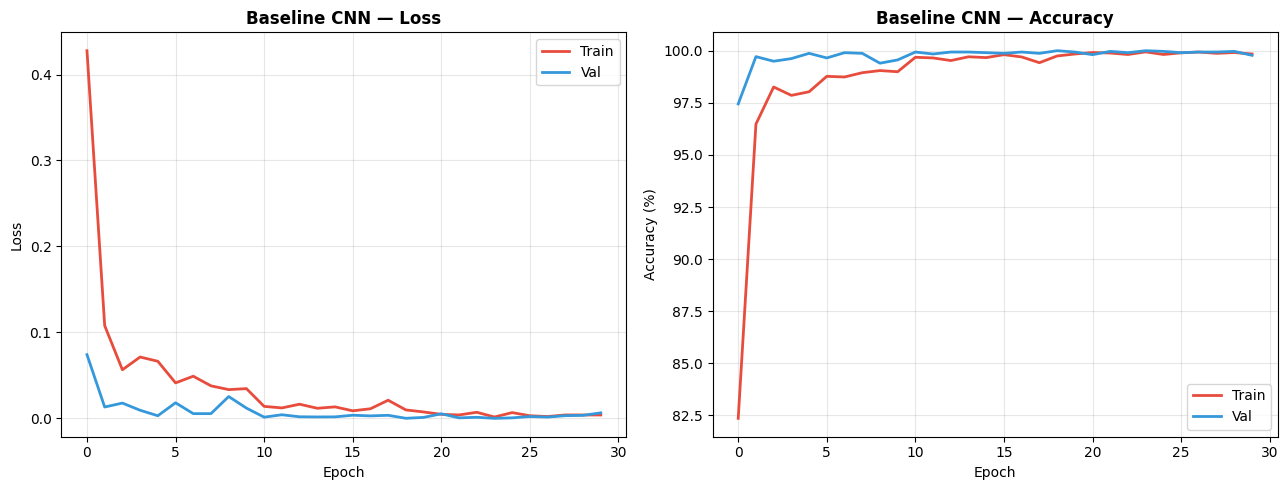

Saved: 04_baseline_curves.png


In [15]:
EPOCHS_BASELINE = 30

loss_fn         = nn.CrossEntropyLoss()
optimizer_base  = optim.AdamW(baseline_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_base  = optim.lr_scheduler.StepLR(optimizer_base, step_size=10, gamma=0.5)

print("=" * 55)
print("TRAINING: Baseline CNN | Optimiser: AdamW | LR: 1e-3")
print("=" * 55)

baseline_model, baseline_history, baseline_time, baseline_best_acc = train_model(
    baseline_model, train_loader, val_loader,
    loss_fn, optimizer_base, scheduler_base,
    num_epochs=EPOCHS_BASELINE, device=DEVICE, model_name="baseline_cnn"
)

plot_training_curves(baseline_history, "Baseline CNN", save_path="04_baseline_curves.png")
print("Saved: 04_baseline_curves.png")

### Evaluate Baseline CNN

EVALUATION: Baseline CNN
  Validation Loss     : 0.0002
  Validation Accuracy : 100.00%

              precision    recall  f1-score   support

     Caution     1.0000    1.0000    1.0000       468
Instructions     1.0000    1.0000    1.0000       574
  No Passing     1.0000    1.0000    1.0000      1088
   OverSpeed     1.0000    1.0000    1.0000      1043

    accuracy                         1.0000      3173
   macro avg     1.0000    1.0000    1.0000      3173
weighted avg     1.0000    1.0000    1.0000      3173



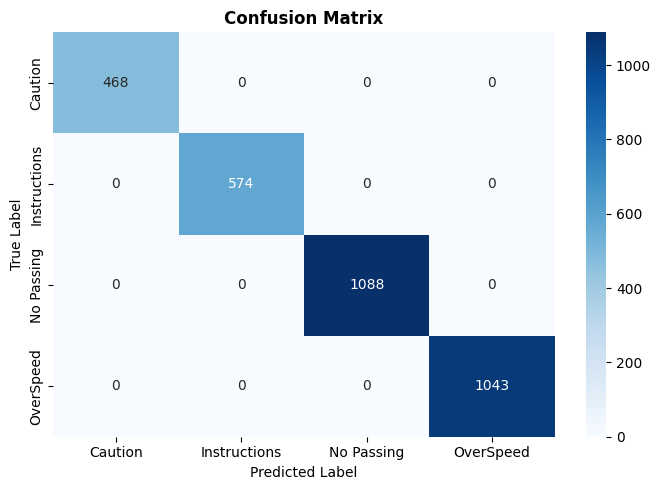

Saved: 05_baseline_cm.png


In [16]:
print("=" * 55)
print("EVALUATION: Baseline CNN")
print("=" * 55)
base_loss, base_acc, base_preds, base_labels = print_evaluation(
    baseline_model, val_loader, loss_fn, DEVICE, CLASS_NAMES,
    save_cm_path="05_baseline_cm.png"
)
print("Saved: 05_baseline_cm.png")

### Baseline CNN — Inference on Validation Samples

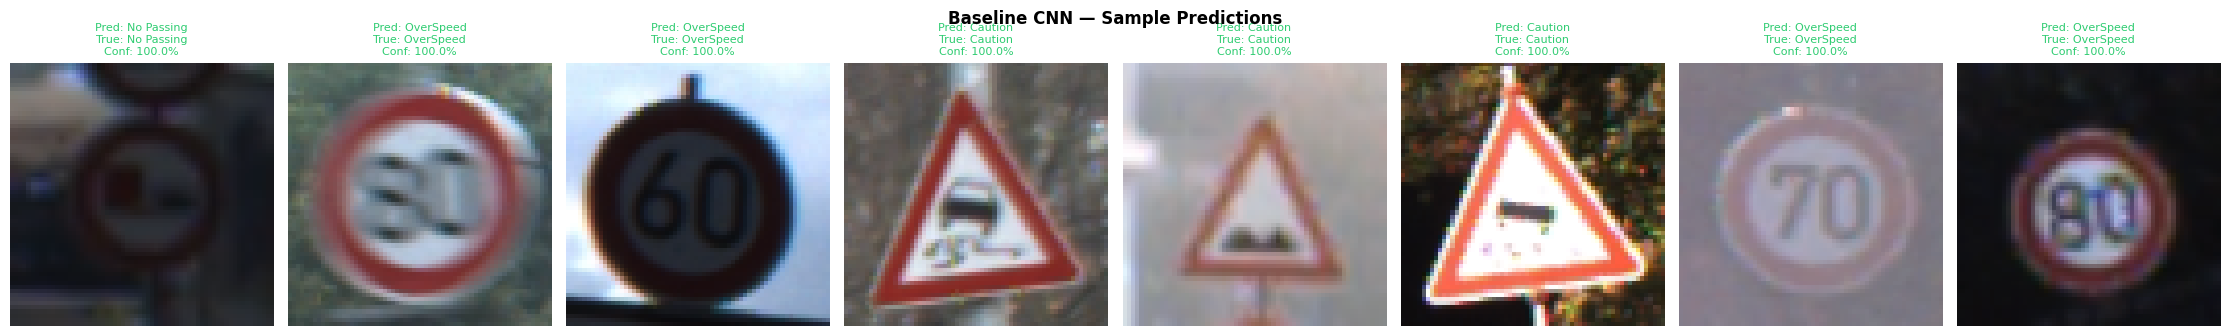

Saved: 06_baseline_predictions.png


In [17]:
def show_sample_predictions(model, loader, class_names, device, n_images=8,
                             title="Predictions", save_path=None):
    """Display n sample predictions with true labels and confidence scores."""
    model.eval()
    images_list, preds_list, labels_list, conf_list = [], [], [], []

    for images, labels in loader:
        with torch.no_grad():
            out   = model(images.to(device))
            probs = F.softmax(out, dim=1)
            preds = probs.argmax(1)
            confs = probs.max(1).values

        for i in range(images.size(0)):
            images_list.append(images[i])
            preds_list.append(preds[i].item())
            labels_list.append(labels[i].item())
            conf_list.append(confs[i].item())
            if len(images_list) >= n_images:
                break
        if len(images_list) >= n_images:
            break

    n = min(n_images, 8)
    fig, axes = plt.subplots(1, n, figsize=(n * 2.8, 3.5))
    if n == 1: axes = [axes]

    for i, ax in enumerate(axes):
        img = denormalise(images_list[i]).permute(1, 2, 0).clamp(0, 1).numpy()
        ax.imshow(img)
        correct = preds_list[i] == labels_list[i]
        color   = "#2ecc71" if correct else "#e74c3c"
        ax.set_title(
            f"Pred: {class_names[preds_list[i]]}\n"
            f"True: {class_names[labels_list[i]]}\n"
            f"Conf: {conf_list[i]*100:.1f}%",
            color=color, fontsize=8
        )
        ax.axis("off")

    plt.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


show_sample_predictions(
    baseline_model, val_loader, CLASS_NAMES, DEVICE,
    n_images=8, title="Baseline CNN — Sample Predictions",
    save_path="06_baseline_predictions.png"
)
print("Saved: 06_baseline_predictions.png")

##  Deeper CNN with Regularisation

### Architecture 
The deeper model doubles the baseline by using **5 blocks with 2 Conv layers each** = 10 Conv layers total (vs 3 in baseline).

| Addition | Why |
|---|---|
| BatchNorm after every Conv | Normalises activations, stabilises training, allows higher LR |
| Dropout2d in early blocks | Spatial dropout — drops entire feature maps, stronger regularisation for CNNs |
| Dropout in FC layers | Prevents co-adaptation of neurons |
| AdaptiveAvgPool at end | Handles any input size, reduces spatial dims to 2×2 before FC |
| Increasing filters 32→512 | Learns progressively more complex features at each level |

In [18]:
class DeeperCNN(nn.Module):
    """
    Deeper CNN — 5 blocks x 2 Conv layers = 10 Conv layers total.
    Regularisation: BatchNorm + Dropout at every stage.
    use_batchnorm flag allows toggling BN off for the ablation study.
    Input : 3 x 64 x 64
    Output: num_classes logits
    """
    def __init__(self, num_classes=4, use_batchnorm=True):
        super().__init__()
        self.use_batchnorm = use_batchnorm

        def conv_layer(in_ch, out_ch):
            """Single Conv → optional BatchNorm → ReLU."""
            layers = [nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)]
            if use_batchnorm:
                layers.append(nn.BatchNorm2d(out_ch))
            layers.append(nn.ReLU(inplace=True))
            return nn.Sequential(*layers)

        # Block 1 — 32 filters | 64×64 → 32×32
        self.block1 = nn.Sequential(
            conv_layer(3,  32), conv_layer(32, 32),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.1)
        )
        # Block 2 — 64 filters | 32×32 → 16×16
        self.block2 = nn.Sequential(
            conv_layer(32, 64), conv_layer(64, 64),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.1)
        )
        # Block 3 — 128 filters | 16×16 → 8×8
        self.block3 = nn.Sequential(
            conv_layer(64, 128), conv_layer(128, 128),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2)
        )
        # Block 4 — 256 filters | 8×8 → 4×4
        self.block4 = nn.Sequential(
            conv_layer(128, 256), conv_layer(256, 256),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2)
        )
        # Block 5 — 512 filters | 4×4 → 2×2 (AdaptiveAvgPool)
        self.block5 = nn.Sequential(
            conv_layer(256, 512), conv_layer(512, 512),
            nn.AdaptiveAvgPool2d((2, 2))   # always outputs 2×2 regardless of input size
        )

        # Classifier — 3 FC layers with heavy dropout
        self.classifier = nn.Sequential(
            nn.Linear(512 * 2 * 2, 1024), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(1024, 512),          nn.ReLU(True), nn.Dropout(0.4),
            nn.Linear(512,  256),          nn.ReLU(True), nn.Dropout(0.3),
            nn.Linear(256,  num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = x.view(x.size(0), -1)     # flatten
        return self.classifier(x)


# Create and summarise
deeper_model = DeeperCNN(num_classes=NUM_CLASSES, use_batchnorm=True).to(DEVICE)
print("=" * 55)
print("DEEPER CNN — Architecture Summary")
print("=" * 55)
print(deeper_model)

total_params     = sum(p.numel() for p in deeper_model.parameters())
trainable_params = sum(p.numel() for p in deeper_model.parameters() if p.requires_grad)
print(f"\nTotal parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

DEEPER CNN — Architecture Summary
DeeperCNN(
  (block1): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.1, inplace=False)
  )
  (block2): Sequential(
    (0): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      

### Train Deeper CNN (AdamW)

TRAINING: Deeper CNN | Optimiser: AdamW | LR: 5e-4
  Epoch   1/40 | Train Loss: 0.5945  Acc: 74.83% | Val Loss: 0.1302  Acc: 95.87%
  Epoch   5/40 | Train Loss: 0.0391  Acc: 98.96% | Val Loss: 0.0013  Acc: 99.97%
  Epoch  10/40 | Train Loss: 0.0176  Acc: 99.58% | Val Loss: 0.0035  Acc: 99.87%
  Epoch  15/40 | Train Loss: 0.0065  Acc: 99.83% | Val Loss: 0.0130  Acc: 99.68%
  Epoch  20/40 | Train Loss: 0.0042  Acc: 99.90% | Val Loss: 0.0000  Acc: 100.00%
  Epoch  25/40 | Train Loss: 0.0021  Acc: 99.94% | Val Loss: 0.0000  Acc: 100.00%
  Epoch  30/40 | Train Loss: 0.0049  Acc: 99.93% | Val Loss: 0.0000  Acc: 100.00%
  Epoch  35/40 | Train Loss: 0.0002  Acc: 100.00% | Val Loss: 0.0000  Acc: 100.00%
  Epoch  40/40 | Train Loss: 0.0017  Acc: 99.99% | Val Loss: 0.0000  Acc: 100.00%

  Best Val Accuracy : 100.00%
  Training Time     : 9868.1s (164.5 min)


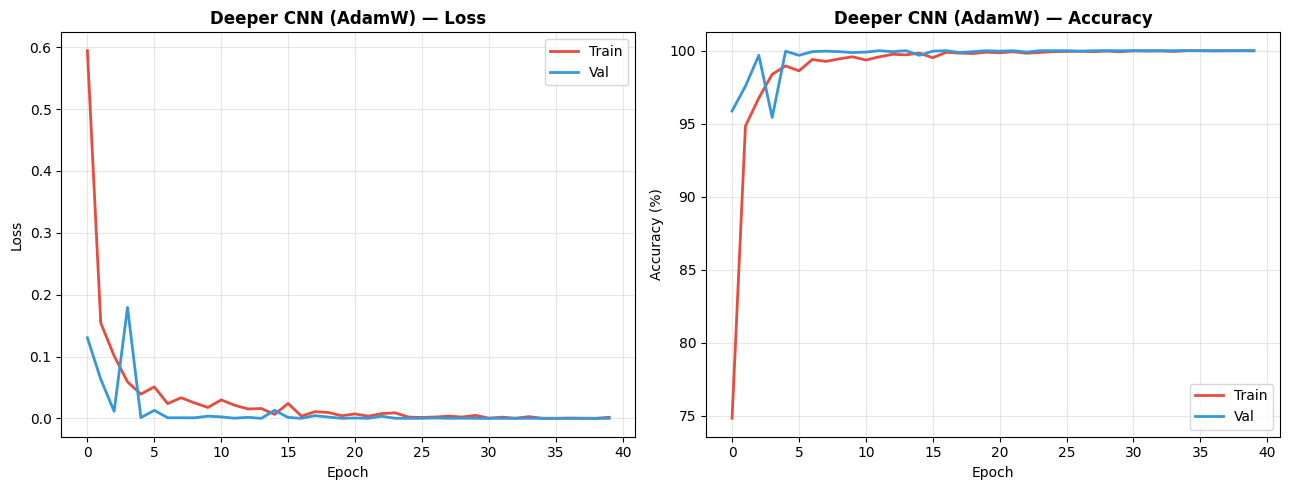

Saved: 07_deeper_adam_curves.png


In [19]:
EPOCHS_DEEPER = 40

optimizer_deep  = optim.AdamW(deeper_model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler_deep  = optim.lr_scheduler.CosineAnnealingLR(optimizer_deep, T_max=EPOCHS_DEEPER)

print("=" * 55)
print("TRAINING: Deeper CNN | Optimiser: AdamW | LR: 5e-4")
print("=" * 55)

deeper_model, deeper_history_adam, deeper_time_adam, deeper_best_adam = train_model(
    deeper_model, train_loader, val_loader,
    loss_fn, optimizer_deep, scheduler_deep,
    num_epochs=EPOCHS_DEEPER, device=DEVICE, model_name="deeper_cnn_adam"
)

plot_training_curves(deeper_history_adam, "Deeper CNN (AdamW)", save_path="07_deeper_adam_curves.png")
print("Saved: 07_deeper_adam_curves.png")

### Evaluate Deeper CNN

EVALUATION: Deeper CNN (AdamW)
  Validation Loss     : 0.0002
  Validation Accuracy : 100.00%

              precision    recall  f1-score   support

     Caution     1.0000    1.0000    1.0000       468
Instructions     1.0000    1.0000    1.0000       574
  No Passing     1.0000    1.0000    1.0000      1088
   OverSpeed     1.0000    1.0000    1.0000      1043

    accuracy                         1.0000      3173
   macro avg     1.0000    1.0000    1.0000      3173
weighted avg     1.0000    1.0000    1.0000      3173



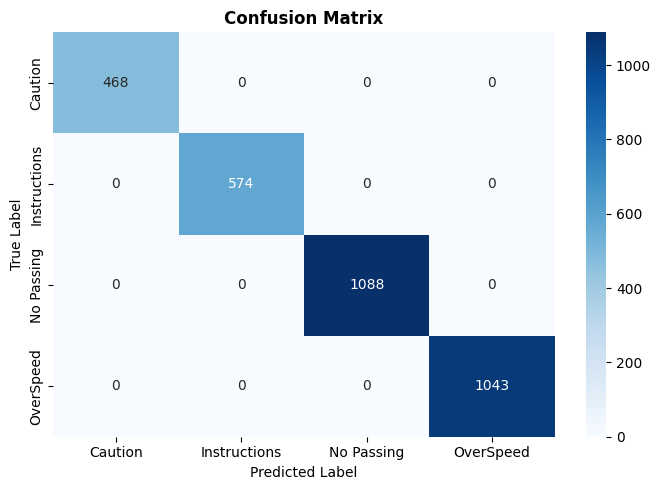

Saved: 08_deeper_adam_cm.png


In [20]:
print("=" * 55)
print("EVALUATION: Deeper CNN (AdamW)")
print("=" * 55)
deep_loss_adam, deep_acc_adam, deep_preds_adam, _ = print_evaluation(
    deeper_model, val_loader, loss_fn, DEVICE, CLASS_NAMES,
    save_cm_path="08_deeper_adam_cm.png"
)
print("Saved: 08_deeper_adam_cm.png")

### Baseline vs Deeper — Side-by-Side Curve Comparison
This is the direct comparison the assignment asks for — both models on the same axes.

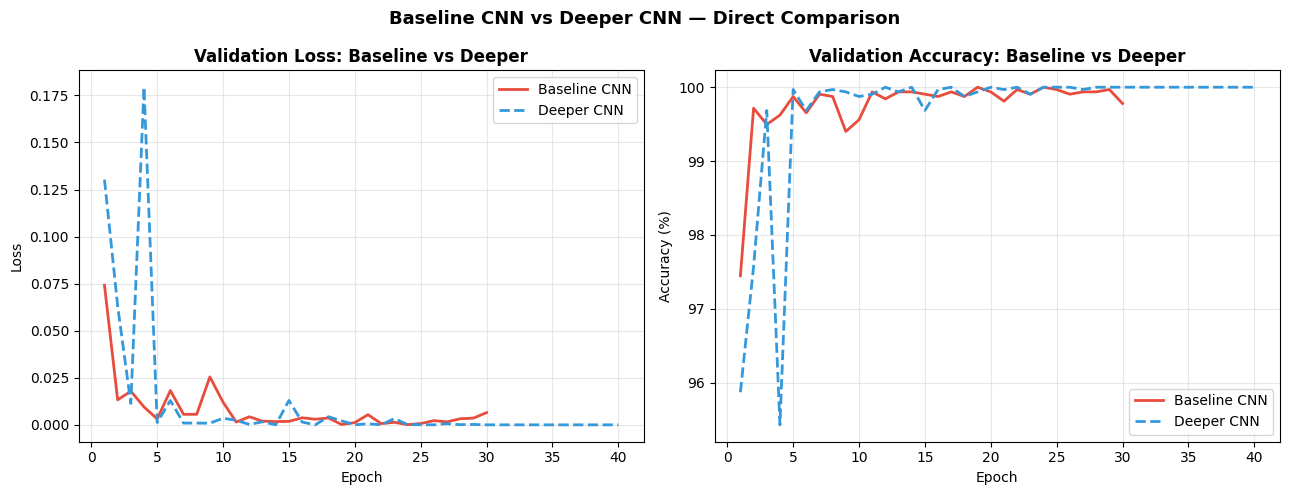

Saved: 09_baseline_vs_deeper.png

Baseline best val acc : 100.00%  (30 epochs)
Deeper   best val acc : 100.00%  (40 epochs)


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

epochs_base  = list(range(1, EPOCHS_BASELINE + 1))
epochs_deep  = list(range(1, EPOCHS_DEEPER   + 1))

# Loss comparison
axes[0].plot(epochs_base, baseline_history["val_loss"],
             label="Baseline CNN", color="#e74c3c", linewidth=2)
axes[0].plot(epochs_deep, deeper_history_adam["val_loss"],
             label="Deeper CNN",   color="#3498db", linewidth=2, linestyle="--")
axes[0].set_title("Validation Loss: Baseline vs Deeper", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy comparison
axes[1].plot(epochs_base, [v*100 for v in baseline_history["val_acc"]],
             label="Baseline CNN", color="#e74c3c", linewidth=2)
axes[1].plot(epochs_deep, [v*100 for v in deeper_history_adam["val_acc"]],
             label="Deeper CNN",   color="#3498db", linewidth=2, linestyle="--")
axes[1].set_title("Validation Accuracy: Baseline vs Deeper", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Baseline CNN vs Deeper CNN — Direct Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("09_baseline_vs_deeper.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 09_baseline_vs_deeper.png")
print(f"\nBaseline best val acc : {baseline_best_acc*100:.2f}%  ({EPOCHS_BASELINE} epochs)")
print(f"Deeper   best val acc : {deeper_best_adam*100:.2f}%  ({EPOCHS_DEEPER} epochs)")


### SGD vs AdamW Optimizer Comparison
Training the same Deeper CNN architecture with SGD to compare convergence speed and final accuracy.

In [22]:
# Fresh model with same architecture for fair SGD comparison
deeper_model_sgd = DeeperCNN(num_classes=NUM_CLASSES, use_batchnorm=True).to(DEVICE)

optimizer_sgd = optim.SGD(
    deeper_model_sgd.parameters(),
    lr=1e-2, momentum=0.9, weight_decay=1e-4, nesterov=True
)
scheduler_sgd = optim.lr_scheduler.CosineAnnealingLR(optimizer_sgd, T_max=EPOCHS_DEEPER)

print("=" * 55)
print("TRAINING: Deeper CNN | Optimiser: SGD + Momentum")
print("=" * 55)

deeper_model_sgd, deeper_history_sgd, deeper_time_sgd, deeper_best_sgd = train_model(
    deeper_model_sgd, train_loader, val_loader,
    loss_fn, optimizer_sgd, scheduler_sgd,
    num_epochs=EPOCHS_DEEPER, device=DEVICE, model_name="deeper_cnn_sgd"
)

TRAINING: Deeper CNN | Optimiser: SGD + Momentum
  Epoch   1/40 | Train Loss: 0.4201  Acc: 83.18% | Val Loss: 0.1093  Acc: 96.09%
  Epoch   5/40 | Train Loss: 0.0837  Acc: 96.93% | Val Loss: 0.0108  Acc: 99.59%
  Epoch  10/40 | Train Loss: 0.0085  Acc: 99.72% | Val Loss: 0.0011  Acc: 99.97%
  Epoch  15/40 | Train Loss: 0.0021  Acc: 99.95% | Val Loss: 0.0000  Acc: 100.00%
  Epoch  20/40 | Train Loss: 0.0008  Acc: 99.98% | Val Loss: 0.0001  Acc: 100.00%
  Epoch  25/40 | Train Loss: 0.0010  Acc: 99.98% | Val Loss: 0.0000  Acc: 100.00%
  Epoch  30/40 | Train Loss: 0.0002  Acc: 99.99% | Val Loss: 0.0000  Acc: 100.00%
  Epoch  35/40 | Train Loss: 0.0004  Acc: 99.98% | Val Loss: 0.0000  Acc: 100.00%
  Epoch  40/40 | Train Loss: 0.0007  Acc: 99.98% | Val Loss: 0.0000  Acc: 100.00%

  Best Val Accuracy : 100.00%
  Training Time     : 9671.7s (161.2 min)


### SGD vs AdamW — Comparison Plot

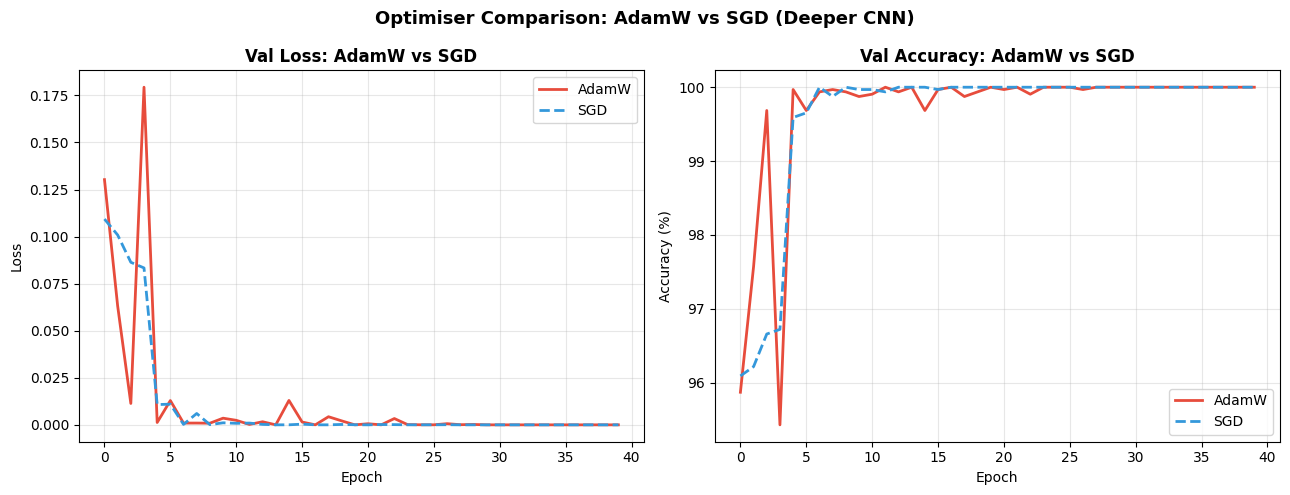

AdamW best val acc : 100.00%  |  Time: 9868.1s
SGD   best val acc : 100.00%  |  Time: 9671.7s
Saved: 10_adamw_vs_sgd.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot([v     for v in deeper_history_adam["val_loss"]],
             label="AdamW", color="#e74c3c", linewidth=2)
axes[0].plot([v     for v in deeper_history_sgd["val_loss"]],
             label="SGD",   color="#3498db", linewidth=2, linestyle="--")
axes[0].set_title("Val Loss: AdamW vs SGD", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot([v*100 for v in deeper_history_adam["val_acc"]],
             label="AdamW", color="#e74c3c", linewidth=2)
axes[1].plot([v*100 for v in deeper_history_sgd["val_acc"]],
             label="SGD",   color="#3498db", linewidth=2, linestyle="--")
axes[1].set_title("Val Accuracy: AdamW vs SGD", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Optimiser Comparison: AdamW vs SGD (Deeper CNN)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("10_adamw_vs_sgd.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"AdamW best val acc : {deeper_best_adam*100:.2f}%  |  Time: {deeper_time_adam:.1f}s")
print(f"SGD   best val acc : {deeper_best_sgd*100:.2f}%  |  Time: {deeper_time_sgd:.1f}s")
print("Saved: 10_adamw_vs_sgd.png")

### Ablation StudyEffect of BatchNorm
Remove BatchNorm from the Deeper CNN to measure how much it contributes to accuracy and stability.

ABLATION: Deeper CNN WITHOUT BatchNorm
  Epoch   1/20 | Train Loss: 0.9811  Acc: 53.01% | Val Loss: 0.2524  Acc: 91.40%
  Epoch   5/20 | Train Loss: 0.1025  Acc: 97.13% | Val Loss: 0.0439  Acc: 99.21%
  Epoch  10/20 | Train Loss: 0.0251  Acc: 99.35% | Val Loss: 0.0065  Acc: 99.81%
  Epoch  15/20 | Train Loss: 0.0083  Acc: 99.80% | Val Loss: 0.0042  Acc: 99.94%
  Epoch  20/20 | Train Loss: 0.0029  Acc: 99.94% | Val Loss: 0.0033  Acc: 99.94%

  Best Val Accuracy : 99.94%
  Training Time     : 4821.8s (80.4 min)


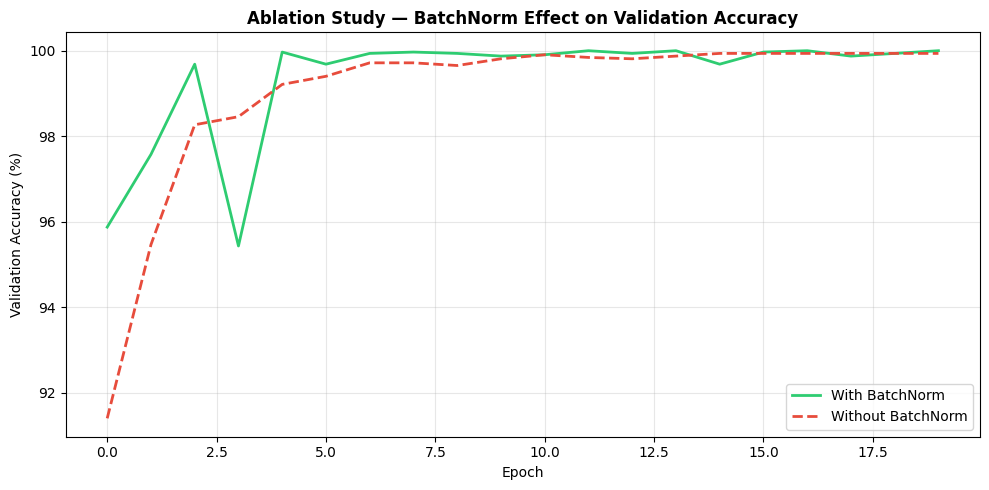

With BatchNorm    : 100.00%
Without BatchNorm : 99.94%
Difference        : 0.06%
Saved: 11_ablation_batchnorm.png


In [24]:
EPOCHS_ABLATION = 20

# Same architecture but BatchNorm disabled
ablation_model    = DeeperCNN(num_classes=NUM_CLASSES, use_batchnorm=False).to(DEVICE)
optimizer_ablation = optim.AdamW(ablation_model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler_ablation = optim.lr_scheduler.CosineAnnealingLR(optimizer_ablation, T_max=EPOCHS_ABLATION)

print("=" * 55)
print("ABLATION: Deeper CNN WITHOUT BatchNorm")
print("=" * 55)

ablation_model, ablation_history, ablation_time, ablation_best_acc = train_model(
    ablation_model, train_loader, val_loader,
    loss_fn, optimizer_ablation, scheduler_ablation,
    num_epochs=EPOCHS_ABLATION, device=DEVICE, model_name="ablation_no_bn"
)

# Compare with vs without BatchNorm
fig, ax = plt.subplots(figsize=(10, 5))
n = EPOCHS_ABLATION
ax.plot([v*100 for v in deeper_history_adam["val_acc"][:n]],
        label="With BatchNorm",    color="#2ecc71", linewidth=2)
ax.plot([v*100 for v in ablation_history["val_acc"]],
        label="Without BatchNorm", color="#e74c3c", linewidth=2, linestyle="--")
ax.set_title("Ablation Study — BatchNorm Effect on Validation Accuracy", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("11_ablation_batchnorm.png", dpi=150, bbox_inches="tight")
plt.show()

with_bn    = max(deeper_history_adam["val_acc"][:n]) * 100
without_bn = ablation_best_acc * 100
print(f"With BatchNorm    : {with_bn:.2f}%")
print(f"Without BatchNorm : {without_bn:.2f}%")
print(f"Difference        : {with_bn - without_bn:.2f}%")
print("Saved: 11_ablation_batchnorm.png")

### Part A  Summary OF ALL MODS


PART A — MODEL COMPARISON SUMMARY
               Model Val Acc (%) Train Time (s) Parameters
Baseline CNN (AdamW)      100.00           7261      ~2.1M
  Deeper CNN (AdamW)      100.00           9868      ~9.2M
    Deeper CNN (SGD)      100.00           9672      ~9.2M
    Ablation (No BN)       99.94           4822      ~8.9M


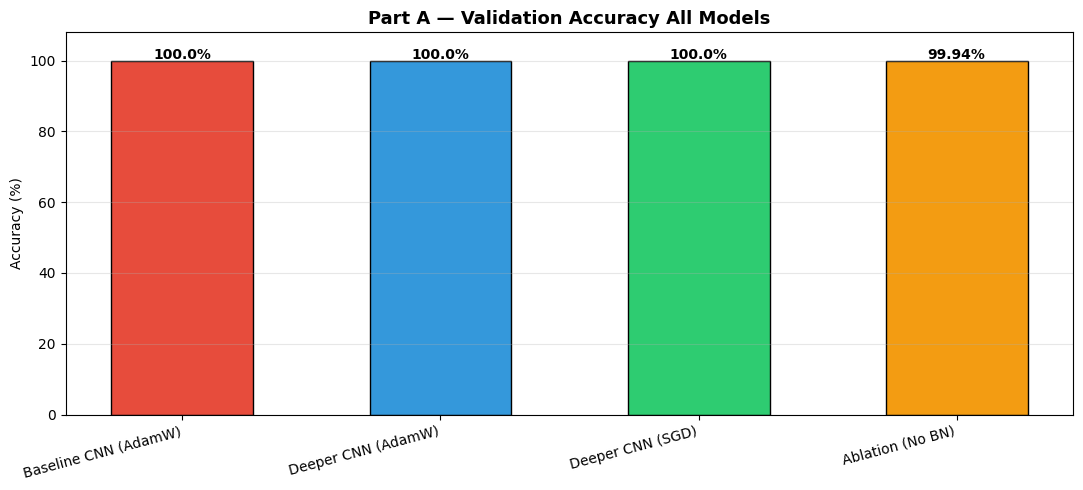

Saved: 12_partA_summary.png


In [25]:
summary_rows = [
    ("Baseline CNN (AdamW)",   f"{base_acc*100:.2f}",
     f"{baseline_time:.0f}",  "~2.1M"),
    ("Deeper CNN (AdamW)",     f"{deep_acc_adam*100:.2f}",
     f"{deeper_time_adam:.0f}","~9.2M"),
    ("Deeper CNN (SGD)",       f"{deeper_best_sgd*100:.2f}",
     f"{deeper_time_sgd:.0f}", "~9.2M"),
    ("Ablation (No BN)",       f"{ablation_best_acc*100:.2f}",
     f"{ablation_time:.0f}",   "~8.9M"),
]

df_summary = pd.DataFrame(summary_rows,
    columns=["Model", "Val Acc (%)", "Train Time (s)", "Parameters"])
print("=" * 65)
print("PART A — MODEL COMPARISON SUMMARY")
print("=" * 65)
print(df_summary.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(11, 5))
accs   = [float(r[1]) for r in summary_rows]
labels = [r[0]        for r in summary_rows]
colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
bars   = ax.bar(labels, accs, color=colors, edgecolor="black", width=0.55)
ax.set_title("Part A — Validation Accuracy All Models", fontsize=13, fontweight="bold")
ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, 108)
plt.xticks(rotation=15, ha="right")
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{acc}%", ha="center", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("12_partA_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 12_partA_summary.png")

## Part B ). Transfer Learning with EfficientNet-B0





### Why EfficientNet-B0?
| Factor | Justification |
|---|---|
| Only 4 classes, hundreds of images per class | Small dataset — need a lightweight model to avoid overfitting |
| Traffic signs are visually simple and structured | Don't need ResNet50's 25M parameters — EfficientNet-B0's 5.3M is enough |
| RTX 3050 with 4GB  | EfficientNet-B0 fits comfortably, ResNet50 risks OOM |
| Compound scaling | EfficientNet balances depth+width+resolution together — proven best accuracy per parameter on small datasets |
| ImageNet pre-training | Already knows edges, shapes, colours — exactly what traffic sign features need |


- Stage 1 — Feature Extraction: freeze entire base, train only new head (15 epochs)
- Stage 2 — Fine-Tuning: unfreeze top blocks, very low LR to avoid catastrophic forgetting (25 epochs)

### DataLoaders for Part B (128×128)

In [26]:
# EfficientNet-B0 works well at 128×128 — saves VRAM vs 224×224
tl_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_TL, IMG_SIZE_TL)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

tl_val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_TL, IMG_SIZE_TL)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

tl_full_dataset          = SafeImageFolder(TRAIN_DIR, transform=tl_train_transform)
tl_full_dataset.img_size = IMG_SIZE_TL

tl_val_size   = int(len(tl_full_dataset) * VAL_SPLIT)
tl_train_size = len(tl_full_dataset) - tl_val_size

tl_train_ds, tl_val_idx = random_split(
    tl_full_dataset, [tl_train_size, tl_val_size],
    generator=torch.Generator().manual_seed(SEED)
)

tl_val_clean          = SafeImageFolder(TRAIN_DIR, transform=tl_val_transform)
tl_val_clean.img_size = IMG_SIZE_TL
tl_val_ds             = Subset(tl_val_clean, tl_val_idx.indices)

tl_train_loader = DataLoader(tl_train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
tl_val_loader   = DataLoader(tl_val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print(f"TL Train : {tl_train_size:,}  |  TL Val : {tl_val_size:,}")
print(f"Batches  : {len(tl_train_loader)} train  |  {len(tl_val_loader)} val")

TL Train : 12,694  |  TL Val : 3,173
Batches  : 794 train  |  199 val


### Load and Modify EfficientNet-B0

In [27]:
# Load ImageNet pre-trained EfficientNet-B0
efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Stage 1: Freeze ALL layers (feature extraction only)
for param in efficientnet.parameters():
    param.requires_grad = False

# Replace the classifier head
# Original: Linear(1280, 1000) for ImageNet
# New     : Linear(1280 → 256 → num_classes) for our 4-class task
in_features = efficientnet.classifier[1].in_features   # 1280

efficientnet.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.2),
    nn.Linear(256, NUM_CLASSES)
)
efficientnet = efficientnet.to(DEVICE)

total_params     = sum(p.numel() for p in efficientnet.parameters())
trainable_params = sum(p.numel() for p in efficientnet.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}  (head only — base is frozen)")
print(f"Frozen params    : {frozen_params:,}")
print(f"\nNew classifier head:")
print(efficientnet.classifier)

Total params     : 4,336,512
Trainable params : 328,964  (head only — base is frozen)
Frozen params    : 4,007,548

New classifier head:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1280, out_features=256, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=256, out_features=4, bias=True)
)


### Feature Extraction (Frozen Base, Train Head Only)

PART B Stage 1 — Feature Extraction
Base: frozen  |  Head: training  |  LR: 1e-3
  Epoch   1/15 | Train Loss: 0.3810  Acc: 85.00% | Val Loss: 0.2464  Acc: 91.52%
  Epoch   5/15 | Train Loss: 0.2187  Acc: 91.52% | Val Loss: 0.1851  Acc: 93.32%
  Epoch  10/15 | Train Loss: 0.1832  Acc: 92.88% | Val Loss: 0.1507  Acc: 94.83%
  Epoch  15/15 | Train Loss: 0.1581  Acc: 94.04% | Val Loss: 0.1399  Acc: 95.52%

  Best Val Accuracy : 95.52%
  Training Time     : 4122.0s (68.7 min)


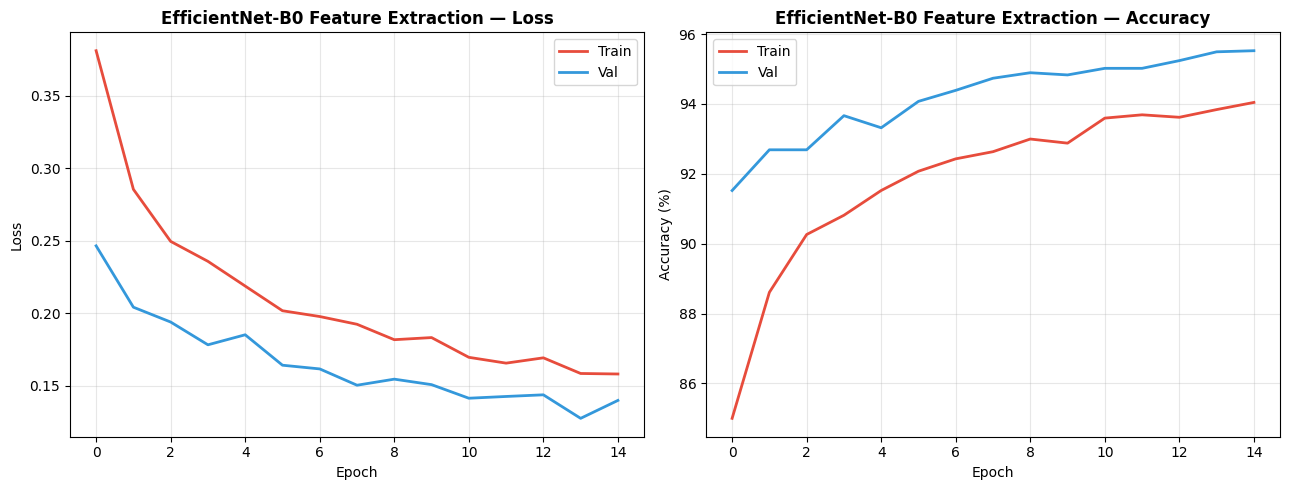

Saved: 13_fe_curves.png


In [28]:
EPOCHS_FEATURE_EXTRACT = 15

# Only optimise the new head parameters
optimizer_fe = optim.AdamW(efficientnet.classifier.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_fe = optim.lr_scheduler.StepLR(optimizer_fe, step_size=5, gamma=0.5)

print("=" * 55)
print("PART B Stage 1 — Feature Extraction")
print("Base: frozen  |  Head: training  |  LR: 1e-3")
print("=" * 55)

efficientnet, fe_history, fe_time, fe_best_acc = train_model(
    efficientnet, tl_train_loader, tl_val_loader,
    loss_fn, optimizer_fe, scheduler_fe,
    num_epochs=EPOCHS_FEATURE_EXTRACT, device=DEVICE, model_name="efficientnet_fe"
)

plot_training_curves(fe_history, "EfficientNet-B0 Feature Extraction",
                     save_path="13_fe_curves.png")
print("Saved: 13_fe_curves.png")

###  Fine-Tuning (Unfreeze Top Blocks + Head)

Trainable params after unfreezing top blocks: 3,072,544
PART B Stage 2 — Fine-Tuning
Top blocks LR: 1e-5  |  Head LR: 1e-4
  Epoch   1/25 | Train Loss: 0.1340  Acc: 94.98% | Val Loss: 0.0943  Acc: 96.75%
  Epoch   5/25 | Train Loss: 0.0709  Acc: 97.41% | Val Loss: 0.0434  Acc: 98.71%
  Epoch  10/25 | Train Loss: 0.0427  Acc: 98.58% | Val Loss: 0.0309  Acc: 98.90%
  Epoch  15/25 | Train Loss: 0.0360  Acc: 98.68% | Val Loss: 0.0203  Acc: 99.37%
  Epoch  20/25 | Train Loss: 0.0360  Acc: 98.69% | Val Loss: 0.0185  Acc: 99.43%
  Epoch  25/25 | Train Loss: 0.0278  Acc: 99.02% | Val Loss: 0.0189  Acc: 99.46%

  Best Val Accuracy : 99.50%
  Training Time     : 6888.4s (114.8 min)


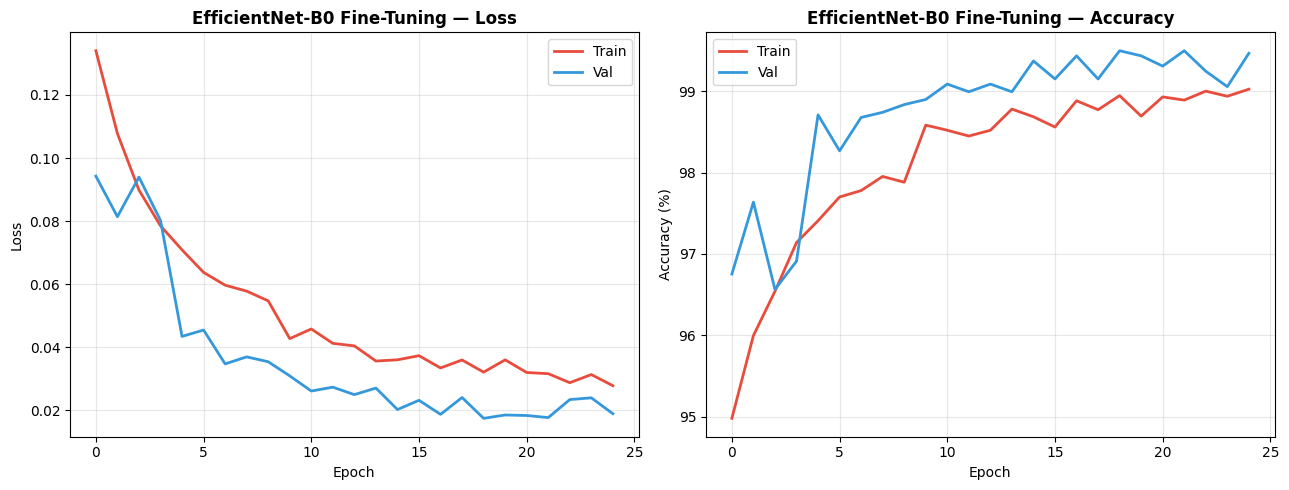

Saved: 14_ft_curves.png


In [29]:
# Unfreeze the last 2 MBConv blocks (features[6], features[7]) + classifier
# Keep earlier blocks frozen to preserve low-level ImageNet features
layers_to_unfreeze = ["features.6", "features.7", "classifier"]

for name, param in efficientnet.named_parameters():
    if any(layer in name for layer in layers_to_unfreeze):
        param.requires_grad = True

trainable_now = sum(p.numel() for p in efficientnet.parameters() if p.requires_grad)
print(f"Trainable params after unfreezing top blocks: {trainable_now:,}")

EPOCHS_FINE_TUNE = 25

# Differential learning rates:
#   - top conv blocks: very low LR to adjust without forgetting
#   - classifier head: normal LR
optimizer_ft = optim.AdamW([
    {"params": [p for n, p in efficientnet.named_parameters()
                if any(l in n for l in ["features.6", "features.7"]) and p.requires_grad],
     "lr": 1e-5},   # very low — avoid catastrophic forgetting
    {"params": efficientnet.classifier.parameters(),
     "lr": 1e-4}    # normal — head can learn faster
], weight_decay=1e-4)

scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=EPOCHS_FINE_TUNE)

print("=" * 55)
print("PART B Stage 2 — Fine-Tuning")
print("Top blocks LR: 1e-5  |  Head LR: 1e-4")
print("=" * 55)

efficientnet, ft_history, ft_time, ft_best_acc = train_model(
    efficientnet, tl_train_loader, tl_val_loader,
    loss_fn, optimizer_ft, scheduler_ft,
    num_epochs=EPOCHS_FINE_TUNE, device=DEVICE, model_name="efficientnet_ft"
)

plot_training_curves(ft_history, "EfficientNet-B0 Fine-Tuning",
                     save_path="14_ft_curves.png")
print("Saved: 14_ft_curves.png")

### Evaluate EfficientNet-B0 (Fine-Tuned)

EVALUATION: EfficientNet-B0 Fine-Tuned
  Validation Loss     : 0.0175
  Validation Accuracy : 99.50%

              precision    recall  f1-score   support

     Caution     0.9873    0.9936    0.9904       468
Instructions     0.9913    0.9895    0.9904       574
  No Passing     0.9982    0.9945    0.9963      1088
   OverSpeed     0.9971    0.9990    0.9981      1043

    accuracy                         0.9950      3173
   macro avg     0.9935    0.9942    0.9938      3173
weighted avg     0.9950    0.9950    0.9950      3173



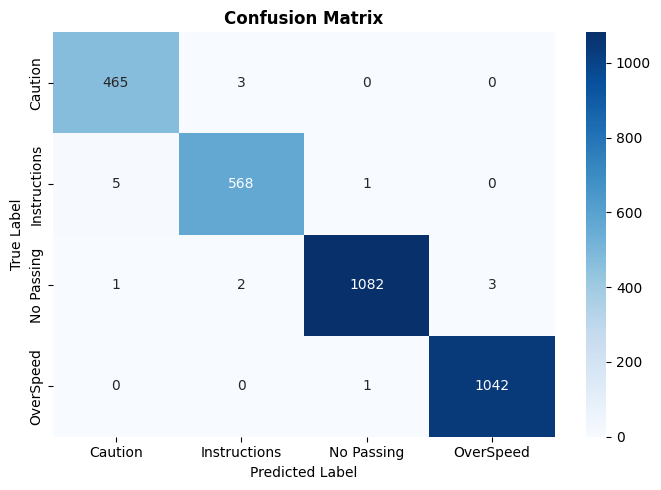

Saved: 15_efficientnet_cm.png


In [30]:
print("=" * 55)
print("EVALUATION: EfficientNet-B0 Fine-Tuned")
print("=" * 55)
ft_loss, ft_acc, ft_preds, ft_labels = print_evaluation(
    efficientnet, tl_val_loader, loss_fn, DEVICE, CLASS_NAMES,
    save_cm_path="15_efficientnet_cm.png"
)
print("Saved: 15_efficientnet_cm.png")

### Inference on Test Images

Test images found: 4


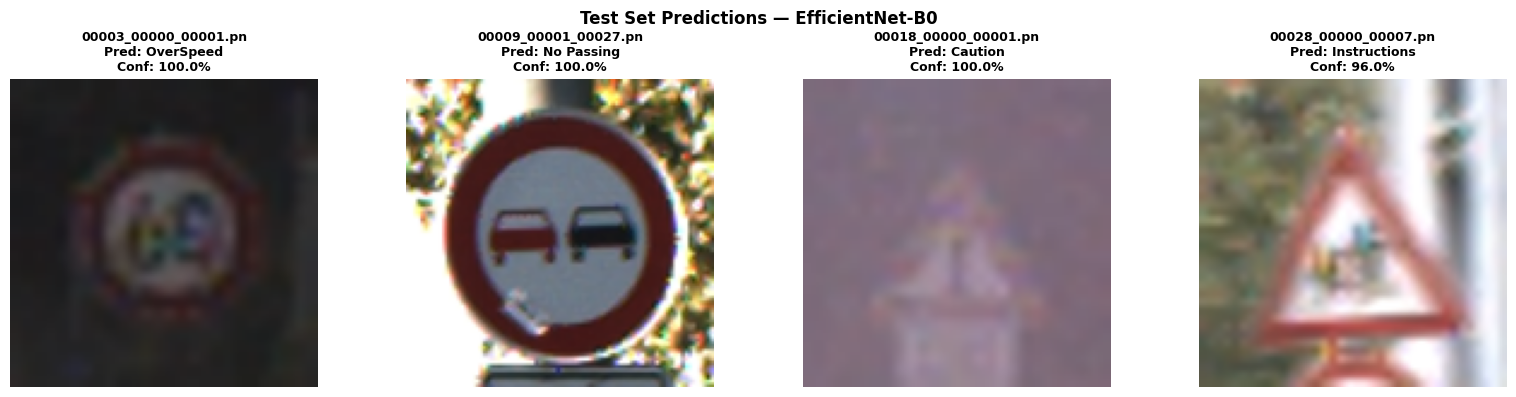

Saved: 16_test_predictions.png

Prediction summary:
  00003_00000_00001.png          → OverSpeed (100.0%)
  00009_00001_00027.png          → No Passing (100.0%)
  00018_00000_00001.png          → Caution (100.0%)
  00028_00000_00007.png          → Instructions (96.0%)


In [31]:
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_TL, IMG_SIZE_TL)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

test_image_files = sorted([
    f for f in Path(TEST_DIR).iterdir()
    if f.suffix.lower() in VALID_EXTENSIONS
])

print(f"Test images found: {len(test_image_files)}")

efficientnet.eval()
test_results = []

for img_path in test_image_files:
    img = load_image_safe(str(img_path))
    if img is None:
        print(f"  Skipping corrupted: {img_path.name}")
        test_results.append((img_path.name, None, None, None))
        continue

    tensor = test_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out   = efficientnet(tensor)
        probs = F.softmax(out, dim=1)[0]
        pred  = probs.argmax().item()
        conf  = probs[pred].item() * 100

    test_results.append((img_path.name, CLASS_NAMES[pred], conf, img))

# Display results
valid_results = [(f, p, c, i) for f, p, c, i in test_results if p is not None]
n = len(valid_results)

if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1: axes = [axes]
    for ax, (fname, pred, conf, img) in zip(axes, valid_results):
        ax.imshow(img.resize((IMG_SIZE_TL, IMG_SIZE_TL)))
        ax.set_title(f"{fname[:20]}\nPred: {pred}\nConf: {conf:.1f}%",
                     fontsize=9, fontweight="bold")
        ax.axis("off")
    plt.suptitle("Test Set Predictions — EfficientNet-B0", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("16_test_predictions.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: 16_test_predictions.png")

print("\nPrediction summary:")
for fname, pred, conf, _ in test_results:
    result = f"{pred} ({conf:.1f}%)" if pred else "CORRUPTED — skipped"
    print(f"  {fname:<30} → {result}")

## Final Comparison. All Models

FINAL COMPARISON — ALL MODELS
                     Model Val Acc (%) Train Time (s) Parameters
              Baseline CNN      100.00           7261      ~2.1M
        Deeper CNN (AdamW)      100.00           9868      ~9.2M
          Deeper CNN (SGD)      100.00           9672      ~9.2M
EfficientNet-B0 Fine-Tuned       99.50           6888      ~5.3M


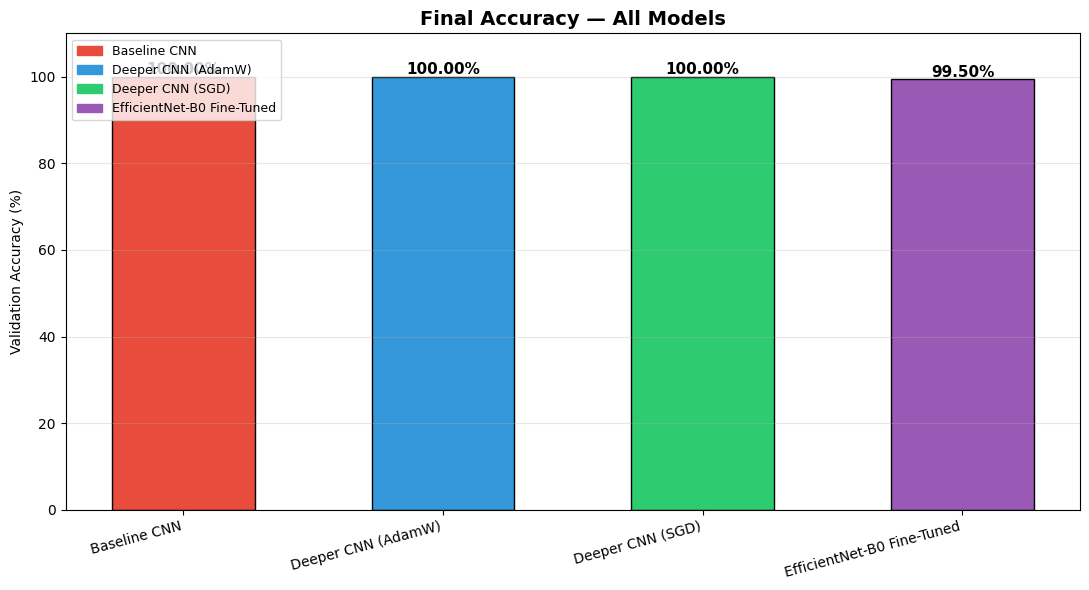

Saved: 17_final_comparison.png


In [32]:
all_models = [
    ("Baseline CNN",              base_acc*100,       baseline_time,       "~2.1M"),
    ("Deeper CNN (AdamW)",        deep_acc_adam*100,  deeper_time_adam,    "~9.2M"),
    ("Deeper CNN (SGD)",          deeper_best_sgd*100,deeper_time_sgd,     "~9.2M"),
    ("EfficientNet-B0 Fine-Tuned",ft_acc*100,         ft_time,             "~5.3M"),
]

df_final = pd.DataFrame(all_models,
    columns=["Model", "Val Acc (%)", "Train Time (s)", "Parameters"])
df_final["Val Acc (%)"]    = df_final["Val Acc (%)"].map("{:.2f}".format)
df_final["Train Time (s)"] = df_final["Train Time (s)"].map("{:.0f}".format)

print("=" * 70)
print("FINAL COMPARISON — ALL MODELS")
print("=" * 70)
print(df_final.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
accs    = [float(r[1]) for r in all_models]
labels  = [r[0]        for r in all_models]
colors  = ["#e74c3c", "#3498db", "#2ecc71", "#9b59b6"]
bars    = ax.bar(labels, accs, color=colors, edgecolor="black", width=0.55)
ax.set_title("Final Accuracy — All Models", fontsize=14, fontweight="bold")
ax.set_ylabel("Validation Accuracy (%)"); ax.set_ylim(0, 110)
plt.xticks(rotation=15, ha="right")
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{acc:.2f}%", ha="center", fontweight="bold", fontsize=11)
patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]
ax.legend(handles=patches, loc="upper left", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("17_final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 17_final_comparison.png")